<a href="https://colab.research.google.com/github/Cesdata/student-dropout-prediction/blob/main/ML2_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Machine Learning: PREDIÇÃO DE DROPOUT DE ALUNOS**

fonte: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

In [ ]:
# Iniciando

import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

!pip install category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.5 MB/s eta 0:00:00


In [ ]:
students = pd.read_csv('https://raw.githubusercontent.com/Cesdata/student-dropout-prediction/refs/heads/main/data.csv', sep=';')
students.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
students.shape

(4424, 37)

In [ ]:
# Preprocessamento

students.nunique().sort_values()

,0
Daytime/evening attendance\t,2
Displaced,2
Debtor,2
Educational special needs,2
International,2
Scholarship holder,2
Gender,2
Tuition fees up to date,2
Target,3
Marital status,6


In [ ]:
# Verificando coluna target

students.Target.value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


In [ ]:
# 'Enrolled' não agregaria no modelo!

students = students.query("Target != 'Enrolled'")
students.Target.value_counts()

,count
Target,
Graduate,2209
Dropout,1421


In [ ]:
# Verificando a proporção sem 'Enrolled'

students.Target.value_counts(1)

,proportion
Target,
Graduate,0.60854
Dropout,0.39146


In [ ]:
# Mapeamento de 0 para 'Graduate' e 1 para 'Dropout'

students['Target'] = students['Target'].map({'Graduate':0, 'Dropout': 1})

In [ ]:
# Colocando o número sem porcentagem

students['Unemployment rate'] = students['Unemployment rate']/100
students['Inflation rate'] = students['Inflation rate']/100

In [ ]:
# Procurando relacionar 'Marital status' com dropout - mais casados desistem

students.groupby('Marital status')['Target'].mean()

,Target
Marital status,
1,0.370116
2,0.547401
3,0.500000
4,0.560000
5,0.500000
6,0.800000


In [ ]:
# Procurando relacionar 'Gender' com dropout - mais mulheres desistem

students.groupby('Gender')['Target'].mean()

,Target
Gender,
0,0.302394
1,0.561249


In [ ]:
# Procurando relacionar 'Debtor' com dropout - os endividados desistem mais

students.groupby('Debtor')['Target'].mean()

,Target
Debtor,
0,0.344731
1,0.755448


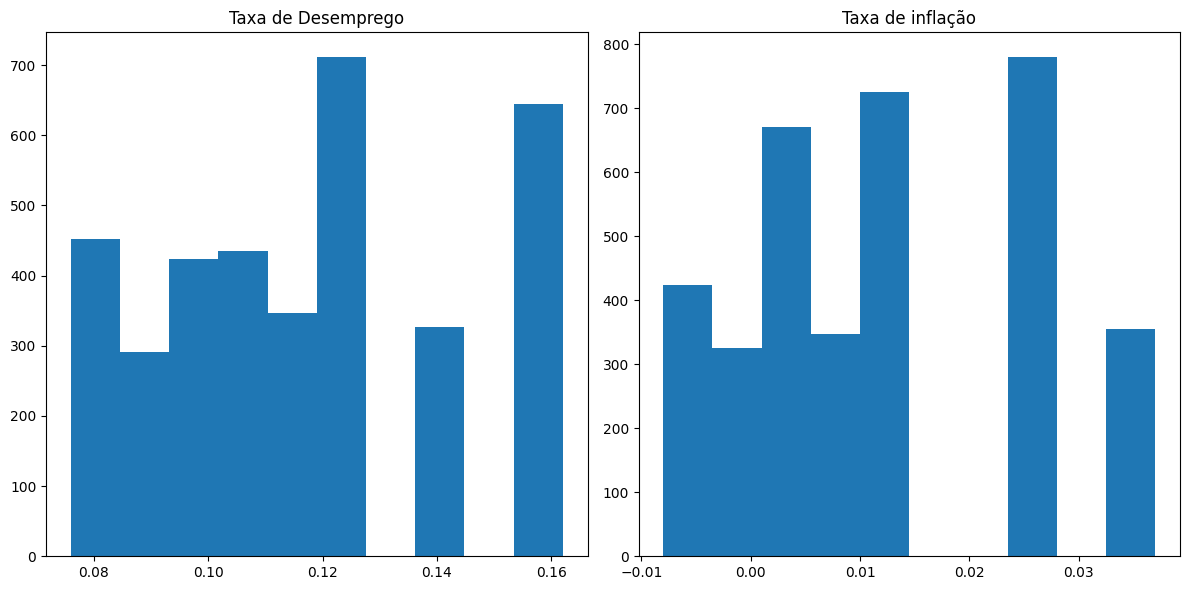

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

plt.title('Taxa desemprego')

plt.sca(axes[0])
plt.hist(students['Unemployment rate'])
plt.title('Taxa de Desemprego')

plt.sca(axes[1])
plt.hist(students['Inflation rate'])
plt.title('Taxa de inflação')

plt.tight_layout()

plt.show()

**Modelo de ML**

In [ ]:
students.rename(columns={'Daytime/evening attendance\t': 'DaytimeEveningAttendance'}, inplace=True)

In [ ]:
numerical_features = ['GDP',
                      'Gender',
                      'Displaced',
                      'International',
                      'Scholarship holder',
                      'Curricular units 1st sem (without evaluations)',
                      'Curricular units 1st sem (credited)',
                      'Curricular units 1st sem (evaluations)',
                      'Curricular units 1st sem (enrolled)',
                      'Curricular units 1st sem (approved)',
                      'Curricular units 1st sem (grade)',
                      'Curricular units 2nd sem (evaluations)',
                      'Curricular units 2nd sem (enrolled)',
                      'Curricular units 2nd sem (credited)',
                      'Curricular units 2nd sem (approved)',
                      'Curricular units 2nd sem (grade)',
                      'Curricular units 2nd sem (without evaluations)',
                      'Age at enrollment',
                      'Tuition fees up to date',
                      'Debtor',
                      'Previous qualification (grade)',
                      'Educational special needs',
                      'Admission grade',
                      'DaytimeEveningAttendance'
                      ]

rate_features = ['Inflation rate', 'Unemployment rate']

ordinal_features = ['Application order']

categorical_features = ['Marital status',
                        "Mother's qualification",
                        "Mother's occupation",
                        "Father's qualification",
                        "Father's occupation",
                        "Nacionality",
                        "Course",
                        "Previous qualification",
                        "Application mode",
                        ]

In [ ]:
for col in categorical_features:
  students[col] = students[col].astype('category')

for col in ordinal_features:
  students[col] = students[col].astype('category')

In [ ]:
target = 'Target'

X = students.drop(target, axis=1)
y = students[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from category_encoders import OrdinalEncoder, TargetEncoder
from sklearn.ensemble import GradientBoostingClassifier

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

rate_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

ordinal_transformer = Pipeline(steps=[
    ('ord_enc', OrdinalEncoder())
])

categorical_transformer = Pipeline(steps=[
    ('targ_enc', TargetEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('rat', rate_transformer, rate_features),
    ('ord', ordinal_transformer, ordinal_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=50, random_state=42))
])

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['GDP', 'Gender', 'Displaced',
                                                   'International',
                                                   'Scholarship holder',
                                                   'Curricular units 1st sem '
                                                   '(without evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(credited)',
                                                   'Curricular units 1st sem '
                                                   '(evaluations)',
                                                   'Curricular units 1st sem '
                                                   '(enrolled)',
                                                   'Curricular u...
                                                  Pipeline(steps=[('ord_enc',
                                                                   OrdinalEncoder())]),
                                                  ['Application order']),
                                                 ('cat',
                                                  Pipeline(steps=[('targ_enc',
                                                                   TargetEncoder())]),
                                                  ['Marital status',
                                                   "Mother's qualification",
                                                   "Mother's occupation",
                                                   "Father's qualification",
                                                   "Father's occupation",
                                                   'Nacionality', 'Course',
                                                   'Previous qualification',
                                                   'Application mode'])])),
                ('classifier',
                 GradientBoostingClassifier(n_estimators=50, random_state=42))])

In [ ]:
y_pred = pipeline.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

print(f'Acurácia: {accuracy_score(y_test, y_pred)}')
print(f'Precision: {precision_score(y_test, y_pred)}')
print(f'Recall: {recall_score(y_test, y_pred)}')
print(f'F1: {f1_score(y_test, y_pred)}')
print(f'ROC AUC: {roc_auc_score(y_test, y_pred)}')



Acurácia: 0.9022038567493113
Precision: 0.912
Recall: 0.8231046931407943
F1: 0.8652751423149905
ROC AUC: 0.8870534601561433


In [ ]:
print ('Matriz de Confusão')
print(confusion_matrix(y_test, y_pred))

Matriz de Confusão
[[427  22]
 [ 49 228]]


In [ ]:
# Classificação de importância

classifier = pipeline.named_steps['classifier']

feature_importances = classifier.feature_importances_

all_features = numerical_features + rate_features + ordinal_features + categorical_features

feature_importances_df = pd.DataFrame({'feature': all_features, 'importance': feature_importances})

feature_importances_df.sort_values('importance', ascending=False)

,feature,importance
14,Curricular units 2nd sem (approved),0.722865
18,Tuition fees up to date,0.082606
8,Curricular units 1st sem (enrolled),0.029221
12,Curricular units 2nd sem (enrolled),0.028190
9,Curricular units 1st sem (approved),0.027988
15,Curricular units 2nd sem (grade),0.017971
33,Course,0.017454
4,Scholarship holder,0.013260
22,Admission grade,0.008338
30,Father's qualification,0.007536


In [ ]:
# Tentar bagunçar uma feature para ver se impacta muito o modelo (testar sua relevância)

feature_importances = {}

features = X_test.columns.tolist()

baseline_metric = accuracy_score(y_test, y_pred)

for feature in features:
  X_test_copy = X_test.copy()
  X_test_copy[feature] = np.random.permutation(X_test_copy[feature])
  y_pred_permuted = pipeline.predict(X_test_copy)
  permuted_metric = accuracy_score(y_test, y_pred_permuted)
  feature_importances[feature] = baseline_metric - permuted_metric


In [ ]:
pd.Series(feature_importances).sort_values(ascending=False)

,0
Curricular units 2nd sem (approved),0.242424
Tuition fees up to date,0.044077
Curricular units 2nd sem (enrolled),0.016529
Curricular units 1st sem (enrolled),0.012397
Curricular units 1st sem (approved),0.005510
Scholarship holder,0.005510
Course,0.005510
Application mode,0.004132
Curricular units 2nd sem (credited),0.002755
Age at enrollment,0.002755
